# Batch Gradient Descent

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# synthetic dataset
from sklearn.datasets import load_diabetes
x,y = load_diabetes(return_X_y=True)

### Firstly training sklearn linear Regression

In [3]:
x.shape

(442, 10)

In [4]:
y.shape

(442,)

In [5]:
# train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=2)

In [6]:
# model training
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [7]:
print(model.coef_) # b1, b2, ...
print(model.intercept_) # b0

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [8]:
y_pred = model.predict(x_test)

In [9]:
# evaluation
from sklearn.metrics import r2_score
r2_linear_reg = r2_score(y_test, y_pred)
r2_linear_reg

0.4399338661568968

In [25]:
# custom class
class GD_regressor():
    def __init__(self, learning_rate, epochs):
        self.lr = learning_rate
        self.epochs = epochs
        self.coef_ = None
        self.intercept_ = None
        self.loss_history = []

    def fit(self, x_train, y_train):
        self.intercept_ = 0
        self.coef_ = np.ones(x_train.shape[1])
        
        for i in range(self.epochs):

            # updating the intercept
            y_pred = self.intercept_ + np.dot(x_train, self.coef_)
            der_intercept = -2 * np.mean(y_train - y_pred)
            self.intercept_ -= (self.lr * der_intercept)

            # updating the coefficients
            der_coef = (-2/x_train.shape[0]) * ((y_train - y_pred) @ x_train)
            self.coef_ -= (self.lr * der_coef)
            
            loss = np.mean((y_train - y_pred)**2)
            self.loss_history.append(loss)

            print(f'step {i} | loss = {loss}')
        
        print('intercept = ',self.intercept_)
        print('coefficients = ',self.coef_)
    
    def predict(self, x_test):
        return self.intercept_ + np.dot(x_test, self.coef_)

In [34]:
gd = GD_regressor(0.1, 1000)
gd.fit(x_train, y_train)

step 0 | loss = 28638.593683644427
step 1 | loss = 20481.66661981615
step 2 | loss = 15258.444528191563
step 3 | loss = 11912.779313745585
step 4 | loss = 9768.744621697531
step 5 | loss = 8393.752966144
step 6 | loss = 7510.951788605656
step 7 | loss = 6943.1576370702
step 8 | loss = 6576.974489580814
step 9 | loss = 6339.829768689658
step 10 | loss = 6185.2775746140305
step 11 | loss = 6083.592872154519
step 12 | loss = 6015.751845648365
step 13 | loss = 5969.579374347357
step 14 | loss = 5937.2834475121035
step 15 | loss = 5913.877209817524
step 16 | loss = 5896.169083048965
step 17 | loss = 5882.116452074903
step 18 | loss = 5870.412029045051
step 19 | loss = 5860.21912978936
step 20 | loss = 5851.002252833001
step 21 | loss = 5842.418651322377
step 22 | loss = 5834.248939925718
step 23 | loss = 5826.352683804809
step 24 | loss = 5818.6399759121705
step 25 | loss = 5811.053246688491
step 26 | loss = 5803.5556224142765
step 27 | loss = 5796.123474647768
step 28 | loss = 5788.7416519

In [35]:
gd_pred = gd.predict(x_test)

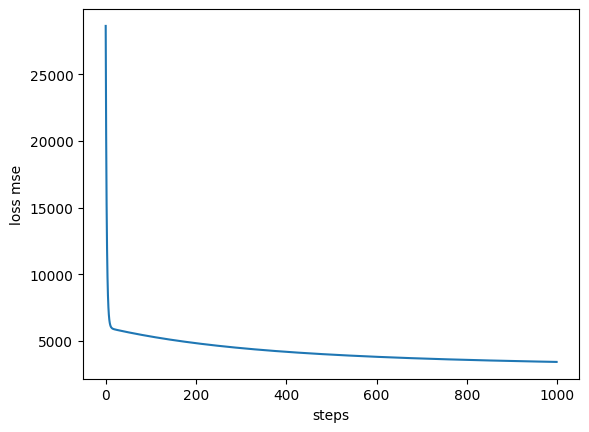

In [36]:
# loss curve
plt.plot(range(gd.epochs), gd.loss_history)
plt.xlabel('steps')
plt.ylabel('loss mse')
plt.show()

In [37]:
r2_score_gd = r2_score(y_test, gd_pred)
r2_score_gd

0.3971698388048742